# MTH/CMSE 314
# IC15: Eigenvalues & Eigenvectors
### <p style="text-align: right;"> &#9989; **Mikel Good** </p>

#### Goals
- Computing characteristic polynomials of a matrix.
- Computing eigenvalues of a matrix.
- Computing eigenvectors for a given eigenvalue.
- Understanding how different Python implementations differ from each other.

#### Please read the following before you begin: 

- <font color=#641e16> We recommended that you complete the After-Class Assignments (ACs) before starting the In-Class Assignments (ICs),
    
- <font color=#641e16> Keep your lecture notes handy for easy reference.

- <font color=#641e16> Use class time to collaborate with your group and get help from instructors, as IC solutions will not be provided.

--------------

&#9989; <font color=blue>**Do this:** Run the cell below before moving on:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import sympy as sym

## Review
<font color=green>**Definition.** Let $A$ be an $n\times n$ matrix.  A non-zero vector $x$ in $\mathbb{R}^n$ is called an **eigenvector** of $A$ such that:

<font color=green>$$Ax=\lambda x$$

<font color=green>for some scalar $\lambda$, which will be called **eigenvalue** corresponding to $x$.

<font color=green>The above can be rewritten as the following homogeneous equation: $(A-\lambda I_n)x = 0$

<font color=green>The trivial solution is $x=0$. To find the eigenvalues, you need the determinant of $A - \lambda I_n $ to be zero, i.e.
$$|A-\lambda I_n| = 0$$ 

<font color=green>Once you know the eigenvalues $\lambda$, you use $(A-\lambda I_n)x = 0$ to find the corresponding eigenvectors.

---
### Solving for eigenvalues and eigenvectors
 &#9989; <font color=blue>**Do this:** Consider the matrix $A = \left[\begin{matrix}  1 & 2 & 0 \\ 2 & 1 & 0 \\ 0 & 0 & 3\end{matrix}\right] $ along with the calculation $\left[\begin{matrix}  1 & 2 & 0 \\ 2 & 1 & 0 \\ 0 & 0 & 3\end{matrix}\right] \left[\begin{matrix}  1 \\  1 \\ 1\end{matrix}\right] =\left[\begin{matrix}  3 \\  3 \\ 3\end{matrix}\right]  $.
Given this, which of the following statements are true?\
        a. 1 is an eigenvalue of $A$.\
        b. 2 is an eigenvalue of $A$.\
        c. 3 is an eigenvalue of $A$.\
        d. $\left[\begin{matrix}  5 \\  5 \\ 5\end{matrix}\right]$ is an eigenvector of $A$\
        e. $\left[\begin{matrix}  1 \\  1 \\ 1\end{matrix}\right]$ is an eigenvector of $A$
        

a. False
b. False
c. True
d. True
e. True

&#9989; <font color=blue>**Problem (BY HAND)**. Find the eigenvalues of $A=\begin{bmatrix}
2 & 3  \\ 
3 & -6    
\end{bmatrix}$ and the corresponding eigenvectors.
    
Import a photo of your calculations or type in latex

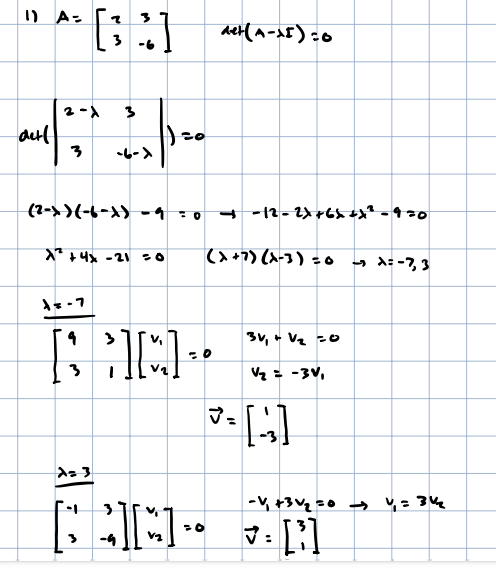

&#9989; <font color=blue>**Problem (BY HAND)**. Find the eigenvalues of $B=\begin{bmatrix}
-1 & 2 & 2 \\ 
2 & 2  & -1 \\
2& -1 & 2
\end{bmatrix}$ and the corresponding eigenvectors.

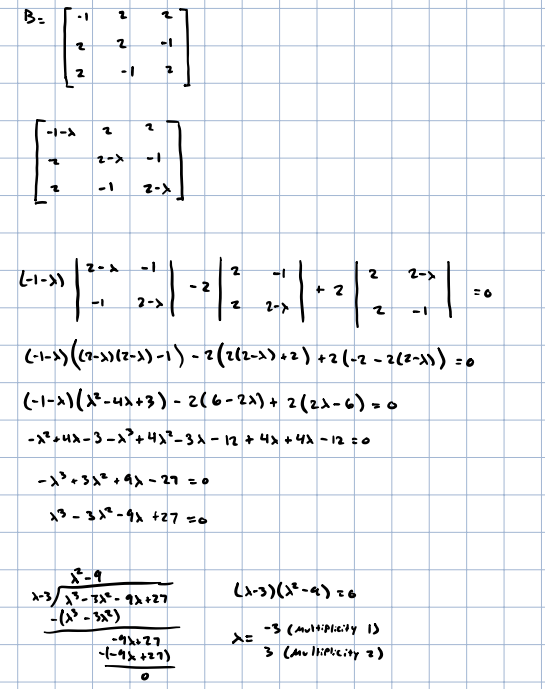

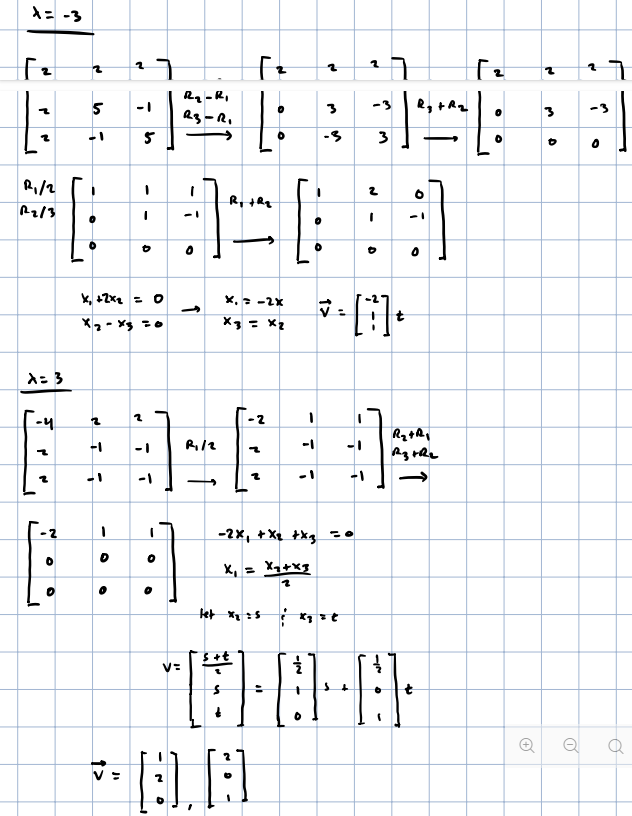

---
### Eigenvalues and eigenvectors with `Numpy`
Here is a way to use the `numpy` library to compute the eigenvalues and eigenvectors of a matrix $A$:

```
A = np.matrix([[4,0,-2],[2,5,4],[0,0,5]])
eigvals, eigvecs = np.linalg.eig(A)
eigvals, eigvecs

```

&#9989; <font color=blue>**Do this:** Use `numpy` to calculate the eigenvalues and eigenvectors of the same matrix $A=\begin{bmatrix}
2 & 3  \\ 
3 & -6    
\end{bmatrix}$ from above. Store the eigenvector associated with the smallest eigenvalue in a vector named ```v1``` and the eigenvector associated with the biggest eigenvalue in a vector named ```v2``` and **compare with the work you did by hand**. 

In [2]:
A = np.matrix([[2,3],[3,-6]])

# put your code here
eigvals, eigvecs = np.linalg.eig(A)
eigvals, eigvecs

(array([ 3., -7.]),
 matrix([[ 0.9486833 , -0.31622777],
         [ 0.31622777,  0.9486833 ]]))

&#9989; <font color=blue>**Do this:** `Sympy` can also compute the eigenvectors/values using some of its own methods. Make $A$ into a `sympy` matrix and call the `.eigenvects()` methods on it. (Bonus: Try `.charpoly()` to retrieve the characteristic polynomial.)

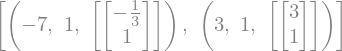

In [4]:
sym.init_printing()

# Put your code here
sym.Matrix(A).eigenvects()

In [5]:
sym.Matrix(A).charpoly()

&#9989; <font color=blue>**Do this:**  Both **sympy** and **numpy** have their own way to produce the eigenvectors and eigenvalues. How are they different?

Sympy's result is the exact eigenvalues and eigenvectors because of the algebraic way of computing it. Numpys version uses floating-point approximations because it is built for speed.

---
### (_Time permitting_) An application of eigenvectors and eigenvalues: Google's PageRank algorithm

We will examine one example of how eigenvectors and eigenvalues are used. Google's patented [Page Rank](https://en.wikipedia.org/wiki/PageRank) algorithm models the web as a network where each page is a node and links are edges. The importance of each page corresponds to the entries of the **dominant eigenvector** of a matrix (the normalized link matrix), whose associated eigenvalue is 1, representing the _steady-state_ distribution of a random web surfer. The underlying assumption is that more important websites are likely to receive more links from other websites. We shall learn more about steady-state vectors in the next lecture.

&#9989; <font color=blue>**Do this:** The next cell is an adaptation of the Python implementation of the `PageRank` algorithm shown in [this Wikipedia page](https://en.wikipedia.org/wiki/PageRank), that will yield the largest eigenvalue (in absolute value) of a matrix $A$. Run the cell.

 <font color=blue>(_Note:_ The term "rank" here refers to the level of importance of a webpage. Do not mistake this with the `rank` of a matrix!)

In [12]:
def pagerank(M, d: float = 0.85):
    """
    Compute PageRank scores using the power iteration method.
    Returns both the final ranks and the history of rank vectors.

    Parameters
    ----------
    M : numpy array
        adjacency matrix where M[i,j] represents the link from 'j' to 'i', 
        such that for all 'j', sum(i, M[i,j]) = 1
    d : float, optional
        damping factor, by default 0.85

    Returns
    -------
    numpy array
        a vector of ranks such that v[i] is the i-th rank from [0, 1].
        
    """
    N = M.shape[1]
    w = np.ones(N) / N
    M_hat = d * M
    v = M_hat @ w + (1 - d) / N

    # Track convergence (for plotting)
    history = [w.copy()]
    while np.linalg.norm(w - v) >= 1e-10:
        w = v
        v = M_hat @ w + (1 - d) / N
        history.append(v.copy())
    
    # Return both the steady-state vector and the history (for plotting)
    return (v / np.sum(v), np.array(history))

``` Next, let's visualize how the algorithm works on a graph and its adjacency matrix. ```

&#9989; <font color=blue>**Do this:** Run the cell below.

In [13]:
def create_custom_network():
    """
    Interactive input: user defines which pages link to which.
    """
    n = int(input("Enter number of pages (nodes): "))
    adj = np.zeros((n, n))

    print("\nDefine links (who links to whom).")
    print("Example: if Page 1 links to Page 3, enter '1 3'. Enter blank line to finish.\n")

    while True:
        link = input("Enter link (from to): ")
        if not link.strip():
            break
        try:
            src, dst = map(int, link.split())
            if 1 <= src <= n and 1 <= dst <= n:
                adj[dst - 1, src - 1] = 1
            else:
                print("❌ Invalid page number.")
        except ValueError:
            print("❌ Please enter two integers (e.g., '1 3').")

    return adj

def visualize_pagerank(adj, ranks, history):
    """
    Show convergence plot and graph visualization.
    """
    n = adj.shape[0]

    # Plot convergence
    plt.figure(figsize=(7, 4))
    for i in range(n):
        plt.plot(history[:, i], label=f"Page {i+1}")
    plt.title("PageRank Convergence")
    plt.xlabel("Iteration")
    plt.ylabel("Rank Value")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot network
    G = nx.DiGraph()
    for i in range(n):
        for j in range(n):
            if adj[i, j] == 1:
                G.add_edge(j+1, i+1)  # j → i

    plt.figure(figsize=(6, 6))
    pos = nx.circular_layout(G)
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color="lightgreen",
        node_size=3000 * ranks,
        arrowsize=20,
        font_size=12,
    )
    plt.title("Custom Web Graph with PageRank Node Sizes")
    plt.show()

&#9989; <font color=blue>**Do this:** Run the next block of code, which will prompt you to create and normalize an adjacency matrix by specifying how many nodes and edges you want, using the functions defined in the previous cell. Then, it creates a plot of page rank convergence, and a graphical visualization of the adjacency matrix. In the first plot, each line shows how the rank of a page stabilizes across iterations of the algorithm. The second plot is a directed graph where:
- <font color=blue> arrows represent links between pages.
- <font color=blue> node size = relative PageRank score.
- <font color=blue> The most _important_ pages (those with more or _stronger_ inbound links) will appear larger. 

Enter number of pages (nodes):  5



Define links (who links to whom).
Example: if Page 1 links to Page 3, enter '1 3'. Enter blank line to finish.



Enter link (from to):  1 2
Enter link (from to):  1 3
Enter link (from to):  1 4
Enter link (from to):  1 5
Enter link (from to):  2 4
Enter link (from to):  3 5
Enter link (from to):  1 2
Enter link (from to):  


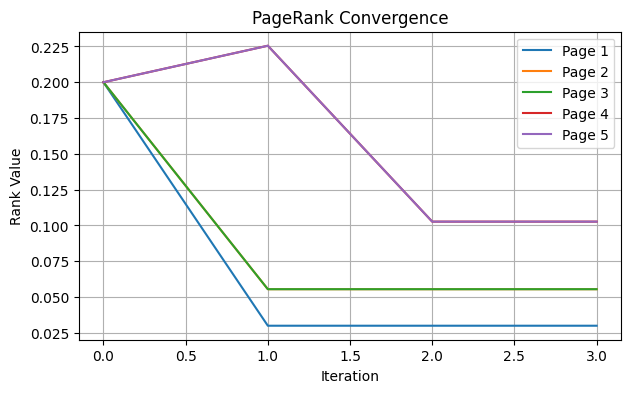

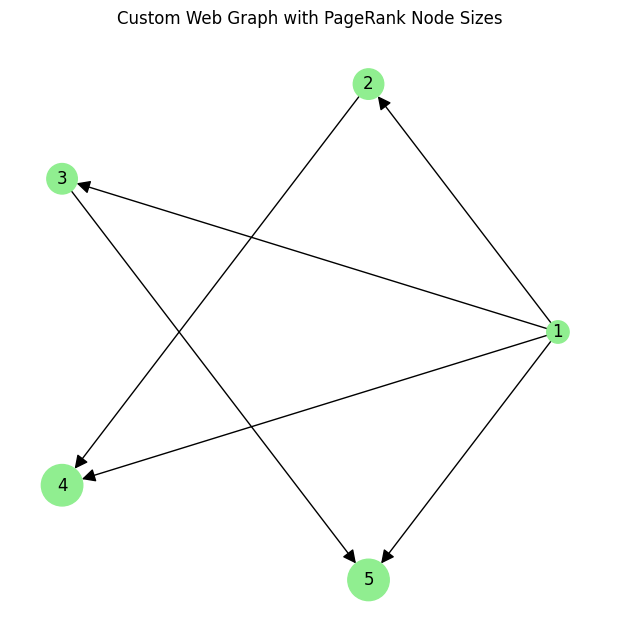


Final PageRank Scores:
Page 1: 0.0866
Page 2: 0.1602
Page 3: 0.1602
Page 4: 0.2964
Page 5: 0.2964


In [17]:
adj = create_custom_network()
ranks, history = pagerank(adj)  # <-- returns two values now
visualize_pagerank(adj, ranks, history)

print("\nFinal PageRank Scores:")
for i, score in enumerate(ranks, start=1):
    print(f"Page {i}: {score:.4f}")

&#9989; <font color=blue>**Do this:** Answer the following questions:
1. <font color=blue> If a very popular page links to a smaller one, how does that affect the smaller page’s rank?
2. <font color=blue> If we change one link in the network, what do you expect to happen to the dominant eigenvector (the ranks)?
3. <font color=blue> Why is the `PageRank` vector always positive and sums to 1?

<font size=+3>&#9998;</font> _put your answer here_ 

---
## Congratulations, you're done!
## Before you close or submit this In-Class Assignment, please make sure of a few things:
- Did you save the file? `Ctrl + S` like everything else works!
- Is the file in correct format? You need to submit this file in `.pdf` format. To do so, `Ctrl + P` and `Save as pdf` (on Windows) or `command + P` in mac.
- If that does not work, please Google "ipynb to pdf converter" and that should do the job.
- Are the pictures/images rendering correctly in the `.pdf` format?
- If the images are not rendering, you could also use this command in a cell:

`from IPython.display import display, Image`

`display(Image(filename="a.jpg", height=400, width=400))`

THIS ONLY WORKS WITH JPGS.
- If this fails, save it as a pdf and merge it with this pdf, perhaps using an online tool (google it!)

- Please double check the contents of the file. One of the most common errors students make is submission of an empty file!